#2A - Exploratory Data Analysis: Global Trade Alert (GTA)

Ground-truth dataset. This notebook characterises the GTA extract that will supply the
prediction **labels**. This notebook implements the exploratory data analysis described in Section 3.4 of the thesis.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
CSV = DATA_DIR / "gta_interventions_2107.csv"
FIG = Path("eda_figures"); FIG.mkdir(exist_ok=True)

mpl.rcParams.update({
    "figure.dpi":120, "savefig.dpi":200, "font.size":11, "font.family":"DejaVu Sans",
    "axes.grid":True, "grid.alpha":0.25, "axes.spines.top":False, "axes.spines.right":False,
    "axes.titlesize":12, "axes.titleweight":"bold", "figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; TEAL="#2E7D6F"; GREY="#7F7F7F"
RED="#B22222"; AMBER="#E1A100"; GREEN="#2E7D32"

df = pd.read_csv(CSV, dtype=str)  
print("Loaded:", CSV, "| shape:", df.shape)
df.head(3)

Loaded: data\gta_interventions_2107.csv | shape: (1605, 19)


,Intervention ID,Intervention URL,State Act ID,State Act URL,State Act Title,GTA Evaluation,Implementing Jurisdictions,Implementation Level,Eligible Firm,Intervention Type,Mast Chapter,Affected Sectors,Affected Products,Affected Jurisdictions,Is Horizontal,Date Announced,Date Implemented,Date Removed,Is In Force
0,12599,https://globaltradealert.org/intervention/12599,9285,https://www.globaltradealert.org/state-act/9285,India: Trade and investment implications of th...,Amber,India,National,all,FDI: Entry and ownership rule,FDI measures,"120, 142, 161, 333, 334, 341, 342, 348, 354, 3...","252800, 261400, 271012, 271019, 271020, 271091...","Algeria, Angola, Argentina, Australia, Austria...",False,2015-02-28,2015-03-01,2016-02-29,0
1,12772,https://globaltradealert.org/intervention/12772,10033,https://www.globaltradealert.org/state-act/10033,Brazil: Tariff-rate quota on human serum albumin,Green,Brazil,National,all,Import tariff,Tariff measures,352,"300212, 300213, 300214, 300215","Austria, Belgium, Canada, China, Denmark, Finl...",False,2015-10-06,2015-10-07,2016-04-06,0
2,12860,https://globaltradealert.org/intervention/12860,10126,https://www.globaltradealert.org/state-act/10126,India: Increase in fund allocation for exports...,Red,India,National,all,Tax-based export incentive,P: Export-related measures (incl. subsidies),"011, 016, 019, 029, 049, 212, 214, 215, 222, 2...","30812, 30819, 40510, 40590, 40630, 40690, 4101...","Afghanistan, Albania, Algeria, Andorra, Angola...",False,2015-10-07,2015-10-07,2016-03-31,0


Each row is a **GTA intervention**, a single trade-policy measure taken by an implementing
jurisdiction, nested under a State Act (the legal instrument, which may contain several
interventions). The unit of analysis for labelling is therefore the intervention, dated by
announcement / implementation / removal.

In [2]:
print("Rows (interventions):", len(df))
print("Unique Intervention IDs:", df['Intervention ID'].nunique(),
      "| duplicated:", df['Intervention ID'].duplicated().sum())
print("Unique State Act IDs   :", df['State Act ID'].nunique(),
      "  (interventions can share a State Act)")
print("\nColumns (", df.shape[1], "):", list(df.columns), sep="")

Rows (interventions): 1605
Unique Intervention IDs: 1605 | duplicated: 0
Unique State Act IDs   : 1331   (interventions can share a State Act)

Columns (19):['Intervention ID', 'Intervention URL', 'State Act ID', 'State Act URL', 'State Act Title', 'GTA Evaluation', 'Implementing Jurisdictions', 'Implementation Level', 'Eligible Firm', 'Intervention Type', 'Mast Chapter', 'Affected Sectors', 'Affected Products', 'Affected Jurisdictions', 'Is Horizontal', 'Date Announced', 'Date Implemented', 'Date Removed', 'Is In Force']


In [3]:
def profile(df):
    rows=[]
    n=len(df)
    for c in df.columns:
        s=df[c]
        nonnull=s.notna().sum()
        rows.append({
            "column":c,
            "dtype_raw":"str",
            "non_null":nonnull,
            "missing_%":round(100*(n-nonnull)/n,1),
            "n_unique":s.nunique(dropna=True),
            "example":(s.dropna().iloc[0][:40]+"...") if nonnull and len(str(s.dropna().iloc[0]))>40
                       else (s.dropna().iloc[0] if nonnull else "")
        })
    return pd.DataFrame(rows)
prof=profile(df)
prof

,column,dtype_raw,non_null,missing_%,n_unique,example
0,Intervention ID,str,1605,0.0,1605,12599
1,Intervention URL,str,1605,0.0,1605,https://globaltradealert.org/interventio...
2,State Act ID,str,1605,0.0,1331,9285
3,State Act URL,str,1605,0.0,1331,https://www.globaltradealert.org/state-a...
4,State Act Title,str,1605,0.0,1328,India: Trade and investment implications...
5,GTA Evaluation,str,1605,0.0,3,Amber
6,Implementing Jurisdictions,str,1605,0.0,44,India
7,Implementation Level,str,1605,0.0,5,National
8,Eligible Firm,str,1605,0.0,7,all
9,Intervention Type,str,1605,0.0,47,FDI: Entry and ownership rule


In [12]:
# Assigned role for each column 
roles = {
 "Intervention ID":"ID (row key)", "Intervention URL":"link (provenance)",
 "State Act ID":"ID (groups interventions)", "State Act URL":"link (provenance)",
 "State Act Title":"descriptive (text; optional NLP later)",
 "GTA Evaluation":"LABEL-relevant (Red/Amber/Green = harm direction)",
 "Implementing Jurisdictions":"FILTER + LABEL (who imposes -> corridor origin)",
 "Implementation Level":"descriptive (national/subnational)",
 "Eligible Firm":"descriptive (all/selected firms)",
 "Intervention Type":"LABEL-relevant (tariff vs other instruments)",
 "Mast Chapter":"LABEL-relevant (MAST taxonomy of measure)",
 "Affected Sectors":"FILTER (CPC sectors)",
 "Affected Products":"FILTER (HS6 -> map to target headings)",
 "Affected Jurisdictions":"FILTER + LABEL (who is hit -> corridor destination)",
 "Is Horizontal":"descriptive (applies to all partners?)",
 "Date Announced":"TEMPORAL (label timing / forecast origin)",
 "Date Implemented":"TEMPORAL (label event time)",
 "Date Removed":"TEMPORAL (right-censoring / duration)",
 "Is In Force":"descriptive (current status; censoring flag)",
}
role_df=pd.DataFrame({"column":list(roles),"assigned_role":list(roles.values())})
role_df

,column,assigned_role
0,Intervention ID,ID (row key)
1,Intervention URL,link (provenance)
2,State Act ID,ID (groups interventions)
3,State Act URL,link (provenance)
4,State Act Title,descriptive (text; optional NLP later)
5,GTA Evaluation,LABEL-relevant (Red/Amber/Green = harm direction)
6,Implementing Jurisdictions,FILTER + LABEL (who imposes -> corridor origin)
7,Implementation Level,descriptive (national/subnational)
8,Eligible Firm,descriptive (all/selected firms)
9,Intervention Type,LABEL-relevant (tariff vs other instruments)


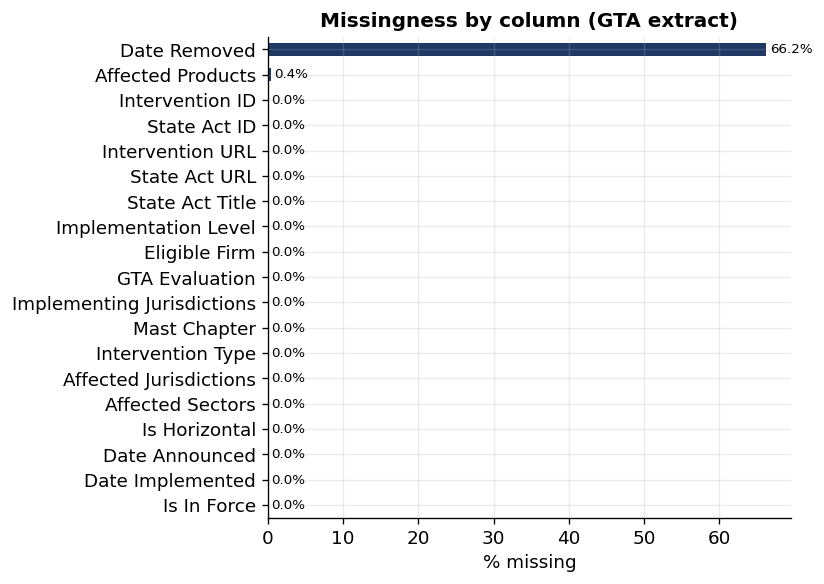

Date Removed                  66.2
Affected Products              0.4
Intervention ID                0.0
State Act ID                   0.0
Intervention URL               0.0
State Act URL                  0.0
State Act Title                0.0
Implementation Level           0.0
Eligible Firm                  0.0
GTA Evaluation                 0.0
Implementing Jurisdictions     0.0
Mast Chapter                   0.0
Intervention Type              0.0
Affected Jurisdictions         0.0
Affected Sectors               0.0
Is Horizontal                  0.0
Date Announced                 0.0
Date Implemented               0.0
Is In Force                    0.0


In [5]:
#Data quality & missing values
n=len(df)
miss=(df.isna().mean()*100).round(1).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(7,5))
miss.plot.barh(ax=ax,color=ACCENT)
ax.set_xlabel("% missing"); ax.set_title("Missingness by column (GTA extract)")
ax.invert_yaxis()
for i,v in enumerate(miss): ax.text(v+0.5,i,f"{v}%",va="center",fontsize=8)
plt.savefig(FIG/"gta_missingness.png",bbox_inches="tight"); plt.show()
print(miss.to_string())

GTA Evaluation:
 GTA Evaluation
Red      1400
Green     192
Amber      13

Tariff-type interventions: 228 (14.2% of extract)

Tariff-type breakdown:
Intervention Type
Import tariff          176
Import tariff quota     52


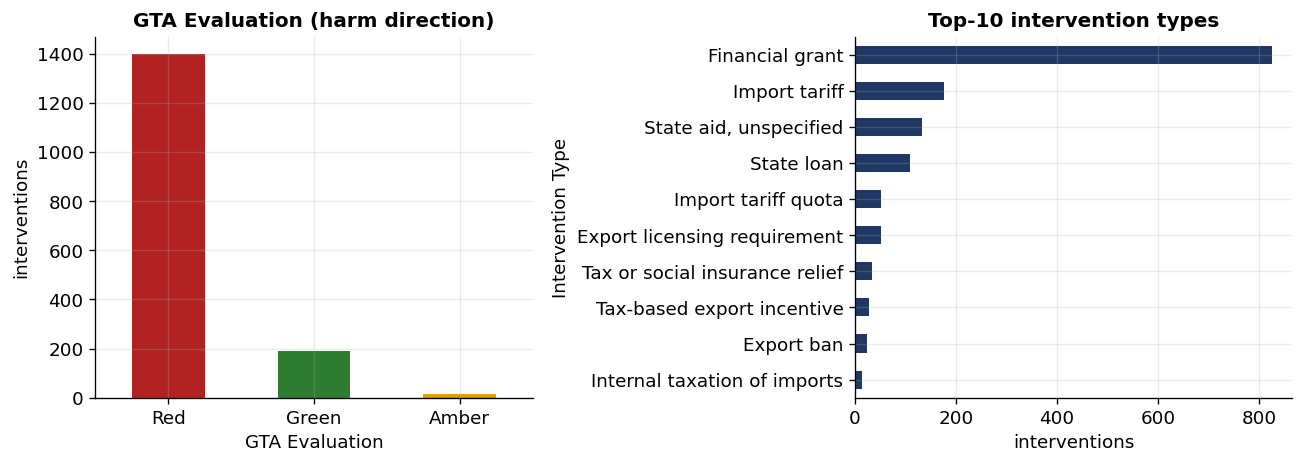

In [6]:
# 4a. GTA Evaluation (harm direction)
ev=df['GTA Evaluation'].value_counts()
# 4b. Intervention Type - is it a tariff?
TARIFF_TYPES = (df['Intervention Type'].str.contains("tariff", case=False, na=False)
             & ~df['Intervention Type'].str.contains("non-tariff", case=False, na=False))  # exclude NTMs
print("GTA Evaluation:\n", ev.to_string())
print("\nTariff-type interventions:", int(TARIFF_TYPES.sum()),
      f"({100*TARIFF_TYPES.mean():.1f}% of extract)")
print("\nTariff-type breakdown:")
print(df.loc[TARIFF_TYPES,'Intervention Type'].value_counts().to_string())

fig,axes=plt.subplots(1,2,figsize=(11,4))
ev.plot.bar(ax=axes[0],color=[RED,GREEN,AMBER][:len(ev)])
axes[0].set_title("GTA Evaluation (harm direction)"); axes[0].set_ylabel("interventions")
axes[0].tick_params(axis='x',rotation=0)
top=df['Intervention Type'].value_counts().head(10)
top.plot.barh(ax=axes[1],color=ACCENT); axes[1].invert_yaxis()
axes[1].set_title("Top-10 intervention types"); axes[1].set_xlabel("interventions")
plt.savefig(FIG/"gta_label_blocks.png",bbox_inches="tight"); plt.show()

 The thesis predicts tariff changes, but the extract is dominated by
Financial grant and other subsidies. This is the single most important labelling fact: the
positive class (tariff events) is a small minority of an already modest dataset. It confirms
the severe class imbalance the modelling must handle, and it dictates that the label be defined
on Intervention Type containing tariff (import tariff, tariff quota), not on any GTA
intervention. GTA Evaluation = Red (trade-harmful) further refines the harmful-tariff signal.

Date ranges:
  Date Announced  : 2015-01-01 -> 2026-03-09 (missing 0.0%)
  Date Implemented: 2015-01-01 -> 2026-09-29 (missing 0.0%)
  Date Removed    : 2015-07-01 -> 2033-12-31 (missing 66.2%)


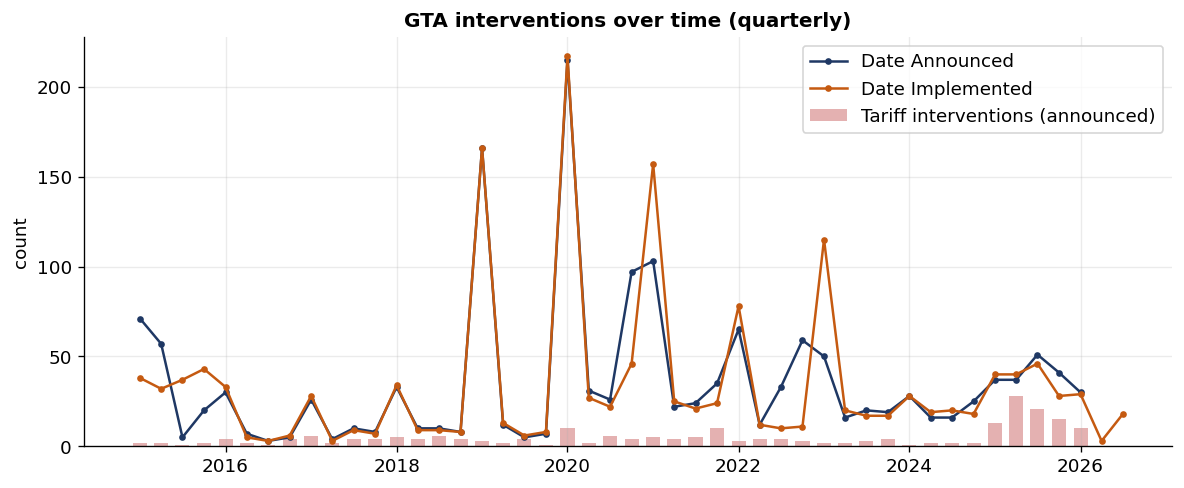

In [7]:
for c in ['Date Announced','Date Implemented','Date Removed']:
    df[c+'_dt']=pd.to_datetime(df[c],errors='coerce')
print("Date ranges:")
for c in ['Date Announced','Date Implemented','Date Removed']:
    s=df[c+'_dt']; print(f"  {c:16s}: {s.min().date() if s.notna().any() else 'NA'} -> "
                         f"{s.max().date() if s.notna().any() else 'NA'} "
                         f"(missing {s.isna().mean()*100:.1f}%)")

fig,ax=plt.subplots(figsize=(10,4.2))
for c,col in [('Date Announced_dt',ACCENT),('Date Implemented_dt',ORANGE)]:
    yr=df[c].dropna().dt.to_period('Q').dt.to_timestamp()
    vc=yr.value_counts().sort_index()
    ax.plot(vc.index,vc.values,marker='o',ms=3,label=c.replace('_dt',''),color=col)
# tariff-only overlay
tt=df.loc[TARIFF_TYPES,'Date Announced_dt'].dropna().dt.to_period('Q').dt.to_timestamp()
vt=tt.value_counts().sort_index()
ax.bar(vt.index,vt.values,width=60,alpha=0.35,color=RED,label='Tariff interventions (announced)')
ax.set_title("GTA interventions over time (quarterly)"); ax.set_ylabel("count"); ax.legend()
plt.savefig(FIG/"gta_temporal.png",bbox_inches="tight"); plt.show()

Announce->implement lag (days): n=1605, median=0, mean=18, p10=0, p90=53, negative(=impl before announce)=33


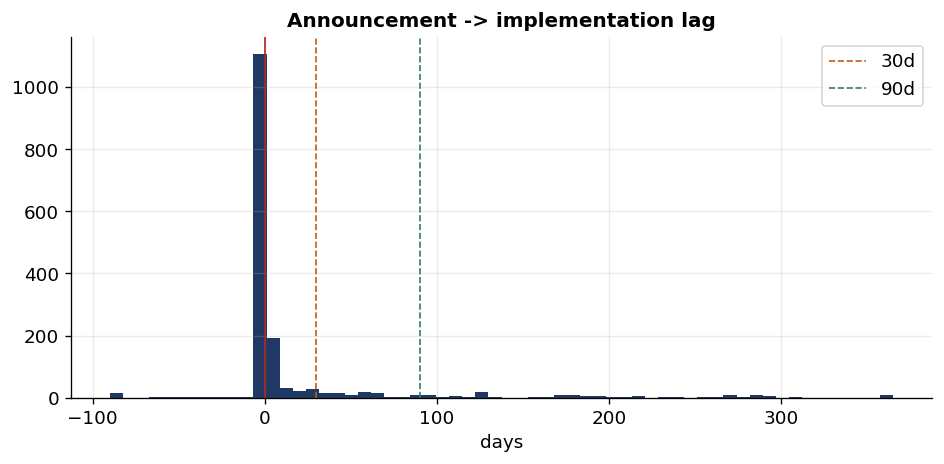

In [8]:
# announcement -> implementation lag (matters for forecast horizon design)
lag=(df['Date Implemented_dt']-df['Date Announced_dt']).dt.days
lag=lag[lag.notna()]
print(f"Announce->implement lag (days): n={len(lag)}, median={lag.median():.0f}, "
      f"mean={lag.mean():.0f}, p10={lag.quantile(.1):.0f}, p90={lag.quantile(.9):.0f}, "
      f"negative(={'impl before announce'})={int((lag<0).sum())}")
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(lag.clip(-90,365),bins=60,color=ACCENT)
ax.axvline(0,color=RED,lw=1); ax.axvline(30,color=ORANGE,ls='--',lw=1,label='30d')
ax.axvline(90,color=TEAL,ls='--',lw=1,label='90d')
ax.set_title("Announcement -> implementation lag"); ax.set_xlabel("days"); ax.legend()
plt.savefig(FIG/"gta_lag.png",bbox_inches="tight"); plt.show()

Tier1 pairs: 18  (table states 17)  | Tier2 pairs: 6
Duplicates within Tier1: 0  within Tier2: 0
OVERLAP Tier1 & Tier2: {('CAN', 'EUR')}


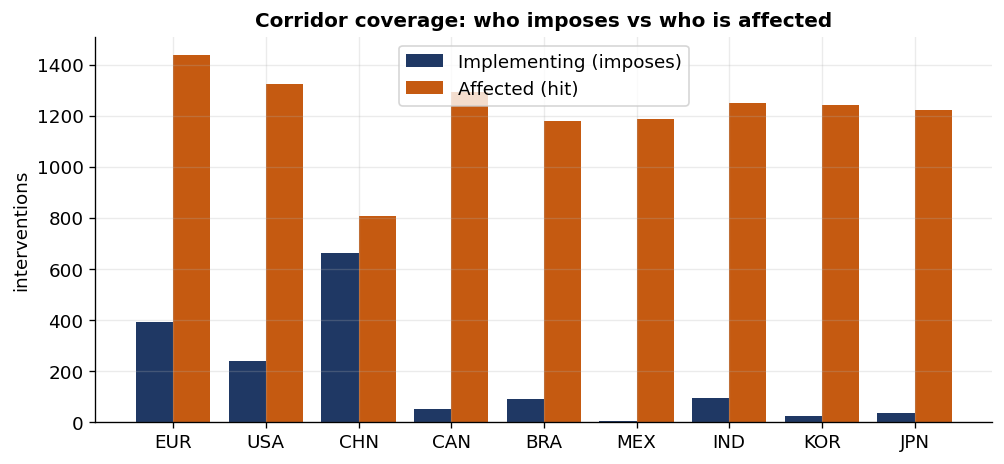

Implementing-entity counts:
 EUR    393
USA    240
CHN    664
CAN     53
BRA     93
MEX      6
IND     94
KOR     25
JPN     37

Affected-entity counts (lists are often near-global; median #affected juris = 60 ):
 EUR    1439
USA    1325
CHN     807
CAN    1292
BRA    1182
MEX    1190
IND    1251
KOR    1244
JPN    1223


In [9]:
EU = {"Austria","Belgium","Bulgaria","Croatia","Cyprus","Czechia","Denmark","Estonia",
 "Finland","France","Germany","Greece","Hungary","Ireland","Italy","Latvia","Lithuania",
 "Luxembourg","Malta","Netherlands","Poland","Portugal","Romania","Slovakia","Slovenia",
 "Spain","Sweden"}
def to_entity(name):
    name=name.strip()
    if name in EU: return "EUR"
    return {"United States of America":"USA","China":"CHN","Canada":"CAN","Brazil":"BRA",
            "Mexico":"MEX","India":"IND","Republic of Korea":"KOR","Japan":"JPN"}.get(name,None)

def entities(cell):
    if pd.isna(cell): return set()
    return {e for e in (to_entity(x) for x in str(cell).split(",")) if e}

df['impl_entities']=df['Implementing Jurisdictions'].apply(entities)
df['aff_entities'] =df['Affected Jurisdictions'].apply(entities)

TIER1=[("EUR","USA"),("EUR","CHN"),("USA","CHN"),("USA","CAN"),("EUR","CAN"),("EUR","BRA"),
 ("USA","BRA"),("EUR","MEX"),("USA","MEX"),("EUR","IND"),("USA","IND"),("CHN","IND"),
 ("CHN","BRA"),("EUR","KOR"),("USA","KOR"),("EUR","JPN"),("CHN","JPN"),("CHN","KOR")]
TIER2=[("USA","JPN"),("CHN","CAN"),("EUR","CAN"),("CHN","MEX"),("JPN","KOR"),("IND","BRA")]
# validation: overlaps / duplicates (flag transcription issues)
s1=set(map(frozenset,TIER1)); s2=set(map(frozenset,TIER2))
print("Tier1 pairs:",len(TIER1)," (table states 17)  | Tier2 pairs:",len(TIER2))
print("Duplicates within Tier1:",len(TIER1)-len(s1)," within Tier2:",len(TIER2)-len(s2))
print("OVERLAP Tier1 & Tier2:",{tuple(sorted(x)) for x in (s1 & s2)})

# how many interventions touch each corridor country?
from collections import Counter
impl=Counter(); aff=Counter()
for _,row in df.iterrows():
    for e in row['impl_entities']: impl[e]+=1
    for e in row['aff_entities']:  aff[e]+=1
ents=["EUR","USA","CHN","CAN","BRA","MEX","IND","KOR","JPN"]
covimpl=pd.Series({e:impl.get(e,0) for e in ents})
covaff =pd.Series({e:aff.get(e,0) for e in ents})
x=np.arange(len(ents)); w=0.4
fig,ax=plt.subplots(figsize=(8.5,4))
ax.bar(x-w/2,covimpl.values,w,label="Implementing (imposes)",color=ACCENT)
ax.bar(x+w/2,covaff.values,w,label="Affected (hit)",color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(ents); ax.set_ylabel("interventions")
ax.set_title("Corridor coverage: who imposes vs who is affected"); ax.legend()
plt.savefig(FIG/"gta_corridor_coverage.png",bbox_inches="tight"); plt.show()
med_aff=int(df['Affected Jurisdictions'].fillna('').apply(lambda s:len([t for t in s.split(',') if t.strip()])).median())
print("Implementing-entity counts:\n",covimpl.to_string())
print("\nAffected-entity counts (lists are often near-global; median #affected juris =",med_aff,"):\n",covaff.to_string())

The overlap check confirms whether the transcribed corridor tables are internally consistent (printed above). Coverage tells us which corridors will actually have positive labels: entities with few interventions will yield near-empty positive
classes, making those lanes unpredictable regardless of model. This is direct evidence for the
two-tier design's rationale (Tier 2 borrows label-rich lanes).

Interventions with an HS product list: 1599
Interventions touching a TARGET heading: 1587 (98.9%)


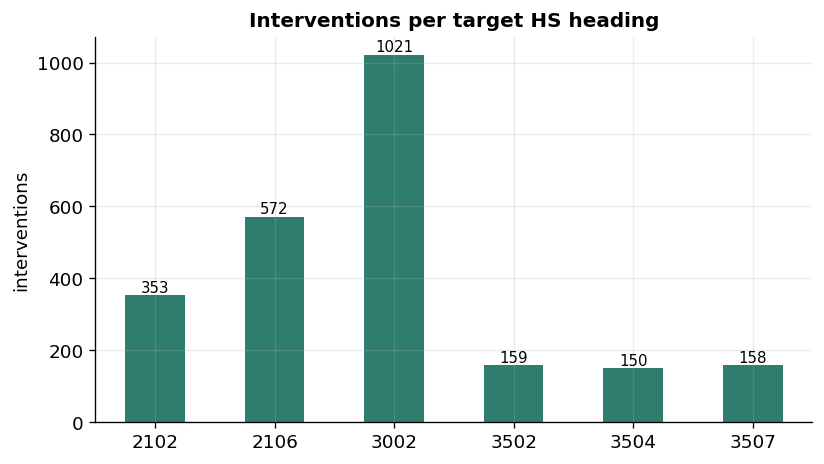


Tariff AND target-HS interventions (label candidates): 228


In [10]:
TARGET_HEADINGS={"2102","2106","3002","3502","3504","3507"}
def headings(cell):
    if pd.isna(cell): return set()
    out=set()
    for tok in str(cell).split(","):
        tok=tok.strip()
        if len(tok)>=4 and tok[:4].isdigit(): out.add(tok[:4])
    return out
df['hs_headings']=df['Affected Products'].apply(headings)
df['hits_target']=df['hs_headings'].apply(lambda s: bool(s & TARGET_HEADINGS))
print("Interventions with an HS product list:", df['Affected Products'].notna().sum())
print("Interventions touching a TARGET heading:", int(df['hits_target'].sum()),
      f"({100*df['hits_target'].mean():.1f}%)")
per={h:int(df['hs_headings'].apply(lambda s: h in s).sum()) for h in sorted(TARGET_HEADINGS)}
fig,ax=plt.subplots(figsize=(7,4))
pd.Series(per).plot.bar(ax=ax,color=TEAL); ax.set_title("Interventions per target HS heading")
ax.set_ylabel("interventions"); ax.tick_params(axis='x',rotation=0)
for i,(k,v) in enumerate(per.items()): ax.text(i,v,str(v),ha='center',va='bottom',fontsize=9)
plt.savefig(FIG/"gta_hs_headings.png",bbox_inches="tight"); plt.show()
# intersection: tariff AND target HS AND corridor -> the true positive-label candidates
core = TARIFF_TYPES & df['hits_target']
print("\nTariff AND target-HS interventions (label candidates):", int(core.sum()))

This is the funnel that produces positive labels: corridor AND
target HS heading AND tariff-type AND (optionally) Red. The count of the intersection is the
realistic ceiling on positive examples - the number that ultimately decides whether the problem
is learnable and how aggressively class imbalance must be handled.

In [11]:
# right-censoring & in-force status
print("Is In Force:", df['Is In Force'].value_counts(dropna=False).to_dict())
print("Date Removed present:", df['Date Removed'].notna().sum(),
      "| implies duration measurable for", df['Date Removed'].notna().sum(),"records")
# implementation-level & horizontal
print("\nImplementation Level:", df['Implementation Level'].value_counts(dropna=False).to_dict())
print("Is Horizontal:", df['Is Horizontal'].value_counts(dropna=False).to_dict())
# announcement clustering by year (reporting-intensity bias proxy)
yr=df['Date Announced_dt'].dt.year.value_counts().sort_index()
print("\nAnnouncements per year:\n", yr.to_string())

Is In Force: {'1': 1179, '0': 426}
Date Removed present: 542 | implies duration measurable for 542 records

Implementation Level: {'National': 1396, 'Supranational': 58, 'IFI': 54, 'NFI': 51, 'Subnational': 46}
Is Horizontal: {'False': 1605}

Announcements per year:
 Date Announced_dt
2015    153
2016     45
2017     48
2018     61
2019    190
2020    369
2021    184
2022    169
2023    105
2024     85
2025    166
2026     30
